In [87]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message="A value is trying to be set on a copy of a DataFrame or Series through chained assignment")
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [88]:
data = pd.read_csv('penguins.csv')
data.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [90]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,344.0,171.500000,99.448479,0.0,85.750,171.50,257.25,343.0
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.50,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.70,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.00,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.00,6300.0
year,344.0,2008.029070,0.818356,2007.0,2007.000,2008.00,2009.00,2009.0


In [91]:
data.columns

Index(['id', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [92]:
data.isnull().sum()

id                    0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [93]:
data.duplicated().sum()

np.int64(0)

In [94]:
print("Number of Rows:",data.shape[0])

Number of Rows: 344


In [95]:
print("Number of Column:",data.shape[1])

Number of Column: 9


In [96]:
#Handling Missing Values

In [97]:
mode_value = data['sex'].mode()[0]

data['sex'].fillna(mode_value, inplace = True)

In [98]:
numerical_columns = data.select_dtypes(include=['float64' , 'int64']).columns
for col in numerical_columns:
    median_value = data[col].median()
    data[col].fillna(median_value, inplace = True)

In [99]:
data.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,male,2007
4,4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,female,2007


In [100]:
data.isnull().sum()

id                   0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

In [101]:
#Correlation Analysis

In [102]:
numerical_data = data.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numerical_data.corr()
correlation_matrix

,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
id,1.000000,0.761484,-0.258242,0.453256,0.274288,0.339103
bill_length_mm,0.761484,1.000000,-0.235000,0.655858,0.594925,0.054285
bill_depth_mm,-0.258242,-0.235000,1.000000,-0.583832,-0.471942,-0.060105
flipper_length_mm,0.453256,0.655858,-0.583832,1.000000,0.871221,0.168954
body_mass_g,0.274288,0.594925,-0.471942,0.871221,1.000000,0.042060
year,0.339103,0.054285,-0.060105,0.168954,0.042060,1.000000


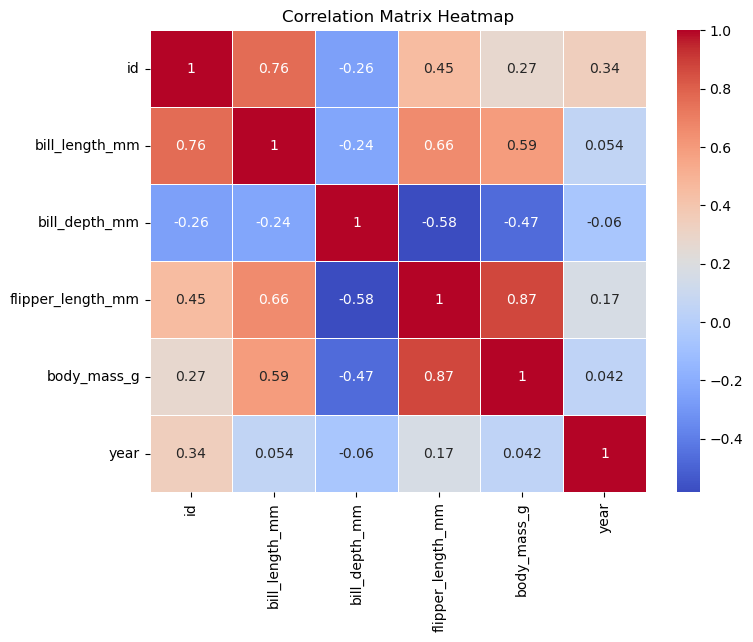

In [103]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [104]:
data['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [105]:


# Count each species
species_count = data['species'].value_counts().reset_index()

# Rename columns
species_count.columns = ['species', 'count']

# Create bar chart
fig = px.bar(
    species_count,
    x='species',
    y='count',
    labels={
        'species': 'Species',
        'count': 'Count'
    },
    title='Species Frequency',
    color='species',
    color_discrete_map={
        'Adelie': 'blue',
        'Gentoo': 'green',
        'Chinstrap': 'orange'
    }
)

fig.update_layout(
    legend_title='Species',
    legend=dict(
        x=0.8,
        y=0.9
    ),
    title_font_size=24,
    xaxis_title_font_size=18,
    yaxis_title_font_size=18,
    xaxis_tickfont_size=14,
    yaxis_tickfont_size=14,
    width=700,
    height=500
)

fig.show()

In [106]:


# Count each island
island_count = data['island'].value_counts().reset_index()

# Rename columns
island_count.columns = ['island', 'count']

# Create bar chart
fig = px.bar(
    island_count,
    x='island',
    y='count',
    labels={
        'island': 'Island',
        'count': 'Count'
    },
    title='Island Frequency',
    color='island',
    color_discrete_map={
        'Biscoe': 'blue',
        'Dream': 'green',
        'Torgersen': 'orange'
    }
)

fig.update_layout(
    legend_title='Island',
    legend=dict(
        x=0.8,
        y=0.9
    ),
    title_font_size=24,
    xaxis_title_font_size=18,
    yaxis_title_font_size=18,
    xaxis_tickfont_size=14,
    yaxis_tickfont_size=14,
    width=700,
    height=500
)

fig.show()

In [107]:

# Count each sex
sex_counts = data['sex'].value_counts().reset_index()

# Rename columns
sex_counts.columns = ['sex', 'count']

# Create bar chart
fig = px.bar(
    sex_counts,
    x='sex',
    y='count',
    labels={
        'sex': 'Sex',
        'count': 'Count'
    },
    title='Sex Count Bar Chart',
    color='sex',
    color_discrete_sequence=['#FFDAB9', '#FF6347'],
    height=400,
    width=600
)

fig.show()

In [108]:
numerical_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for column in numerical_columns:
    fig = px.violin(data, 
                    y=column, 
                    color='species',  
                    box=True,         
                    points='all',      
                    title=f'{column}',
                    labels={column: column}
                   )
    
    fig.update_layout(
        title_font_size=24,
        xaxis_title_font_size=18,
        yaxis_title_font_size=18,
        xaxis_tickfont_size=14,
        yaxis_tickfont_size=14,
        width=700,
        height=500,
    )
    
    fig.show()

In [109]:
data['year'].value_counts()

year
2009    120
2008    114
2007    110
Name: count, dtype: int64

In [110]:
year_counts = data['year'].value_counts().reset_index()
year_counts.columns = ['year', 'count']

fig = px.pie(
    year_counts,
    names='year',  
    values='count', 
    title='Distribution of Data Over Years',
    color='year',  
    height=500,  
    width=800  
)

fig.update_layout(
    legend_title='Year'
)

fig.show()

In [111]:
#Bivariate Analysis

In [112]:
custom_colors = ['#FF9999', '#66B2FF', '#99FF99'] 

fig = px.histogram(
    data,
    x='sex',
    color='island',
    color_discrete_sequence=custom_colors,  
    title='Sex of Penguins by Island',
    labels={'sex': 'Sex', 'island': 'Island'},
    height=500,  
    width=800   
)

fig.update_layout(
    xaxis_title='Sex',
    yaxis_title='Count',
    legend_title='Island'
)

fig.show()

In [113]:
custom_colors = ['#FF9999', '#66B2FF', '#99FF99'] 

fig = px.histogram(
    data,
    x='sex',
    color='species',
    color_discrete_sequence=custom_colors,  
    title='Sex of Penguins by Species',
    labels={'sex': 'Sex', 'species': 'Species'},
    height=500,  
    width=800   
)

fig.update_layout(
    xaxis_title='Sex',
    yaxis_title='Count',
    legend_title='Species'
)

fig.show()

In [114]:
custom_colors = ['#FF9999', '#66B2FF', '#99FF99'] 

fig = px.histogram(
    data,
    x='island',
    color='species',
    color_discrete_sequence=custom_colors,  
    title='Island of Penguins by Species',
    labels={'island': 'Island', 'species': 'Species'},
    height=500,  
    width=800   
)

fig.update_layout(
    xaxis_title='Island',
    yaxis_title='Count',
    legend_title='Species'
)

fig.show()


In [115]:
fig = px.scatter(
    data,
    x='bill_length_mm',
    y='bill_depth_mm',
    color='bill_length_mm',  
    color_continuous_scale='Viridis',  
    title='Scatter Plot of Bill Length vs. Bill Depth',
    labels={'bill_length_mm': 'Bill Length (mm)', 'bill_depth_mm': 'Bill Depth (mm)'},
    height=500,
    width=800
)

fig.update_layout(
    xaxis_title='Bill Length (mm)',
    yaxis_title='Bill Depth (mm)',
    coloraxis_colorbar=dict(title='Bill Length (mm)')
)

fig.show()

In [116]:
fig = px.scatter(
    data,
    x='bill_length_mm',
    y='flipper_length_mm',
    color='bill_length_mm',  
    color_continuous_scale='Greens',  
    title='Scatter Plot of Bill Length vs. Bill Depth',
    labels={'bill_length_mm': 'Bill Length (mm)', 'flipper_length_mm': 'Flipper Length (mm)'},
    height=500,
    width=800
)

fig.update_layout(
    xaxis_title='Bill Length (mm)',
    yaxis_title='Flipper Length (mm)',
    coloraxis_colorbar=dict(title='Bill Length (mm)')
)

fig.show()

In [117]:
fig = px.scatter(
    data,
    x='bill_length_mm',
    y='body_mass_g',
    color='bill_length_mm',  
    color_continuous_scale='Burg',  
    title='Scatter Plot of Bill Length vs. body_mass_g',
    labels={'bill_length_mm': 'Bill Length (mm)', 'body_mass_g': 'Body Mass (g)'},
    height=500,
    width=800
)

fig.update_layout(
    xaxis_title='Bill Length (mm)',
    yaxis_title='Body Mass (g)',
    coloraxis_colorbar=dict(title='Bill Length (mm)')
)

fig.show()

In [118]:
fig = px.scatter(
    data,
    x='bill_depth_mm',
    y='flipper_length_mm',
    color='bill_depth_mm',  
    color_continuous_scale='Magenta',  
    title='Scatter Plot of Bill Depth vs. Flipper Length',
    labels={'bill_depth_mm': 'Bill Depth (mm)', 'flipper_length_mm': 'Flipper Length (mm)'},
    height=500,
    width=800
)

fig.update_layout(
    xaxis_title='Bill Depth (mm)',
    yaxis_title='Flipper Length (mm)',
    coloraxis_colorbar=dict(title='Bill Depth (mm)')
)

fig.show()

In [119]:
fig = px.scatter(
    data,
    x='bill_depth_mm',
    y='body_mass_g',
    color='bill_depth_mm',  
    color_continuous_scale='Teal',  
    title='Scatter Plot of Bill Depth vs. Body Mass',
    labels={'bill_depth_mm': 'Bill Depth (mm)', 'body_mass_g': 'Body Mass (g)'},
    height=500,
    width=800
)

fig.update_layout(
    xaxis_title='Bill Depth (mm)',
    yaxis_title='Body Mass (g)',
    coloraxis_colorbar=dict(title='Bill Depth (mm)')
)

fig.show()

In [120]:
fig = px.scatter(
    data,
    x='flipper_length_mm',  
    y='body_mass_g',        
    color='flipper_length_mm',  
    color_continuous_scale='RdPu', 
    title='Scatter Plot of Flipper Length vs. Body Mass',
    labels={'flipper_length_mm': 'Flipper Length (mm)', 'body_mass_g': 'Body Mass (g)'},
    height=500,
    width=800
)

fig.update_layout(
    xaxis_title='Flipper Length (mm)',
    yaxis_title='Body Mass (g)',
    coloraxis_colorbar=dict(title='Flipper Length (mm)')
)

fig.show()


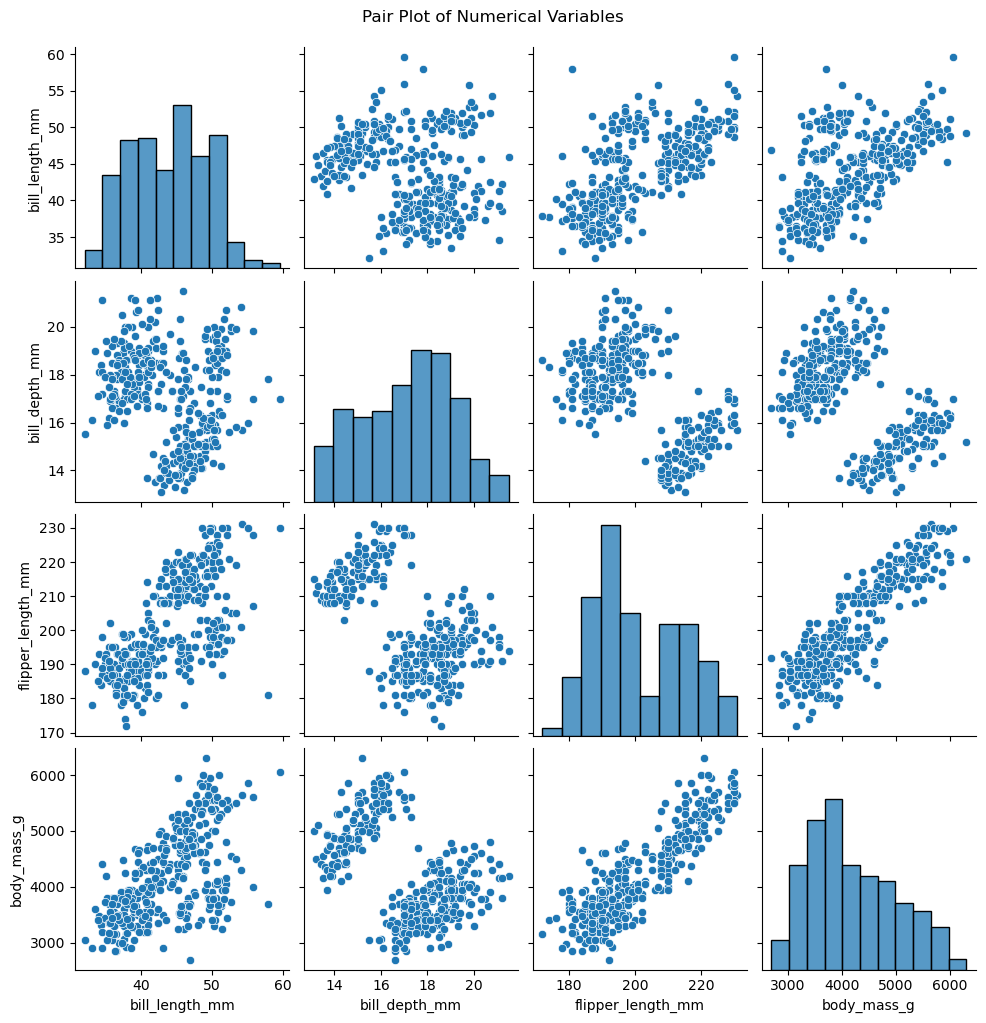

In [121]:
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
data_subset = data[numerical_cols]

sns.pairplot(data_subset)
plt.suptitle('Pair Plot of Numerical Variables', y=1.02) 

plt.show()